In [3]:
import kagglehub
import os

dataset_path = kagglehub.dataset_download('mohamedmustafa/real-life-violence-situations-dataset')
data_dir = os.path.join(dataset_path, 'Real Life Violence Dataset')
print('Data source import complete.')

Data source import complete.


In [ ]:

import numpy as np
import pandas as pd


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
     for filename in filenames:
         print(os.path.join(dirname, filename))



In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import Library

In [6]:
import os
import shutil
import cv2
import math
import random
import numpy as np
import datetime as dt
import tensorflow
import keras
from collections import deque
from collections import deque
import seaborn as sns
sns.set_theme()

%matplotlib inline

from sklearn.model_selection import train_test_split

from keras.layers import *
from keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

# Visualize the Data

In [ ]:
from IPython.display import HTML
from base64 import b64encode

# To Show a Video in Notebook
def Play_Video(filepath):
    html = ''
    video = open(filepath,'rb').read()
    src = 'data:video/mp4;base64,' + b64encode(video).decode()
    html += '<video width=640 muted controls autoplay loop><source src="%s" type="video/mp4"></video>' % src
    return HTML(html)

Extracting Frames

In [5]:
non_violence_videos_path = "/content/drive/MyDrive/IS/archive (2)/Real Life Violence Dataset/NonViolence"
violence_videos_path = "/content/drive/MyDrive/IS/archive (2)/Real Life Violence Dataset/Violence"

non_violence_video_list = os.listdir(non_violence_videos_path)
violence_video_list = os.listdir(violence_videos_path)

random_non_violence_video = random.choice(non_violence_video_list)
random_violence_video = random.choice(violence_video_list)

In [ ]:
display(Play_Video(f"{non_violence_videos_path}/{random_non_violence_video}"))


In [ ]:
display(Play_Video(f"{violence_videos_path}/{random_violence_video}"))

In [4]:
frame_height, frame_width = 96, 96
sequence_length = 16

dataset_path = "/content/drive/MyDrive/IS/archive (2)/Real Life Violence Dataset"

class_labels = ["NonViolence", "Violence"]

print(frame_height)

96


Opens the video file.

Calculates the interval to skip frames to get sequence_length frames.

Loops through the video, extracting frames at the calculated interval.

Resizes each extracted frame to (frame_height, frame_width).

Normalizes pixel values to be between 0 and 1.

Stores the frames in a list.

Returns the list of extracted frames.

In [7]:
def extract_frames(video_path):
    """Extract a fixed number of frames from a video file."""
    frames = []

    video_capture = cv2.VideoCapture(video_path)
    if not video_capture.isOpened():
        raise ValueError(f"Error opening video file: {video_path}")

    total_frames = int(video_capture.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames == 0:
        video_capture.release()
        raise ValueError(f"Video has no frames: {video_path}")

    frame_interval = max(total_frames // sequence_length, 1)

    for frame_index in range(sequence_length):
        video_capture.set(cv2.CAP_PROP_POS_FRAMES, frame_index * frame_interval)
        success, frame = video_capture.read()
        if not success:
            print(f"Warning: Could not read frame {frame_index} from {video_path}")
            break

        resized_frame = cv2.resize(frame, (frame_width, frame_height))
        normalized_frame = resized_frame.astype('float32') / 255.0
        frames.append(normalized_frame)

    video_capture.release()

    if len(frames) != sequence_length:
        print(f"Warning: Extracted frames ({len(frames)}) less than required ({sequence_length}) for {video_path}")

    return frames

# Build Dataset

What it does:

Creates a dataset for training the violence detection model.
Organizes video frames and labels for machine learning.
How it works:

Iterates through each class label (e.g., "NonViolence", "Violence").

Finds all video files within each class's directory.

For each video:

Extracts frames using extract_frames function.

If enough frames are extracted, adds them to the features list.

Assigns the corresponding label (0 for "NonViolence", 1 for "Violence").

Stores the video path for reference.

Converts features and labels into NumPy arrays.

Returns the features, labels, and video paths.

In [ ]:
def build_dataset(dataset_path, class_labels, sequence_length, frame_extraction_func):
    """Create a dataset by extracting frames from videos and assigning labels."""
    features, labels, video_paths = [], [], []

    for class_index, class_name in enumerate(class_labels):
        print(f"Processing class: {class_name} ({class_index + 1}/{len(class_labels)})")

        class_dir = os.path.join(dataset_path, class_name)
        video_files = [f for f in os.listdir(class_dir) if f.endswith('.mp4') or f.endswith('.avi')]

        for video_file in video_files:
            video_path = os.path.join(class_dir, video_file)
            try:
                frames = frame_extraction_func(video_path)
                if len(frames) == sequence_length:
                    features.append(frames)
                    labels.append(class_index)
                    video_paths.append(video_path)
                else:
                    print(f"Skipping {video_file}: Not enough frames ({len(frames)}).")
            except Exception as e:
                print(f"Error processing {video_file}: {e}")

    features = np.asarray(features, dtype=np.float32)
    labels = np.array(labels, dtype=np.int32)

    print(f"Dataset creation completed: {len(features)} samples collected.")
    return features, labels, video_paths


In [ ]:
features, labels, video_paths = build_dataset(dataset_path, class_labels, sequence_length, extract_frames)


In [ ]:
np.save("/content/drive/MyDrive/Honours/features.npy",features)
np.save("/content/drive/MyDrive/Honours/labels.npy",labels)
np.save("/content/drive/MyDrive/Honours/video_paths.npy",video_paths)

In [7]:
features, labels, video_paths = np.load("/content/drive/MyDrive/IS/Honours/features.npy") , np.load("/content/drive/MyDrive/IS/Honours/labels.npy") ,  np.load("/content/drive/MyDrive/IS/Honours/video_paths.npy")

# Encoding and Splitting Training-Testing Sets

The primary reason for converting labels into one-hot encoded vectors is to make them compatible with the way many machine learning algorithms, especially those using categorical cross-entropy loss, handle categorical data.

Explanation:

Categorical Data: In this case, the labels represent categories ("NonViolence" and "Violence"). While they can be represented as numerical values (0 and 1), directly using these numbers can mislead the model into thinking there's an ordinal relationship between the categories (e.g., that "Violence" is somehow "greater" than "NonViolence").

In [9]:
one_hot_encoded_labels = to_categorical(labels)

In [10]:
features_train, features_test, labels_train, labels_test = train_test_split(features, one_hot_encoded_labels, test_size = 0.1,
                                                                            shuffle = True, random_state = 42)

In [11]:
print(features_train.shape,labels_train.shape )
print(features_test.shape, labels_test.shape)

(1800, 16, 96, 96, 3) (1800, 2)
(200, 16, 96, 96, 3) (200, 2)


# Importing MobileNet and Fine-Tuning it

ImageNet provides the foundation of pre-trained knowledge, and MobileNetV2 leverages this knowledge to efficiently extract features for violence detection. This approach saves training time and often improves performance compared to training from scratch. I hope this concise explanation clarifies the relationship. Let me know if you have any other questions.

In [ ]:
from tensorflow.keras.applications import MobileNetV2


mobile_net_model = MobileNetV2(weights= "imagenet", include_top=False, input_shape=(frame_height, frame_width, 3))

mobile_net_model.trainable = True
for layer in mobile_net_model.layers[:-40]:
    layer.trainable = False

mobile_net_model.summary()


Model: "mobilenetv2_1.00_96"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 96, 96, 3)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 48, 48, 32)     │            864 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 48, 48, 32)     │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 48, 48, 32)     │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 48, 48, 32)     │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 48, 48, 32)     │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 48, 48, 32)     │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 48, 48, 16)     │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 48, 48, 16)     │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 48, 48, 96)     │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 48, 48, 96)     │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 48, 48, 96)     │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 49, 49, 96)     │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 24, 24, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├──────────────────────

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 1,681,536 (6.41 MB)

 Non-trainable params: 576,448 (2.20 MB)

# Building The Model

In [ ]:
from tensorflow.keras.regularizers import l2

def build_model():
    model = Sequential()

    model.add(Input(shape=(sequence_length, frame_height, frame_width, 3)))

    model.add(TimeDistributed(mobile_net_model))

    model.add(TimeDistributed(BatchNormalization()))

    model.add(Dropout(0.3))

    model.add(TimeDistributed(Flatten()))

    lstm_forward = LSTM(units=64, kernel_regularizer=l2(0.01))
    lstm_backward = LSTM(units=64, go_backwards=True, kernel_regularizer=l2(0.01))

    model.add(Bidirectional(lstm_forward, backward_layer=lstm_backward))

    model.add(BatchNormalization())

    model.add(Dropout(0.3))

    model.add(Dense(256, activation='relu', kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.3))

    model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.3))

    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.3))

    model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.3))

    model.add(Dense(len(class_labels), activation='softmax'))

    model.summary()

    return model

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ time_distributed_3 (TimeDistributed) │ (None, 16, 3, 3, 1280)      │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_4 (TimeDistributed) │ (None, 16, 3, 3, 1280)      │           5,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 16, 3, 3, 1280)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_5 (TimeDistributed) │ (None, 16, 11520)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 128)                 │       5,931,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 2)                   │              66 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,271,458 (31.55 MB)

 Trainable params: 7,692,194 (29.34 MB)

 Non-trainable params: 579,264 (2.21 MB)

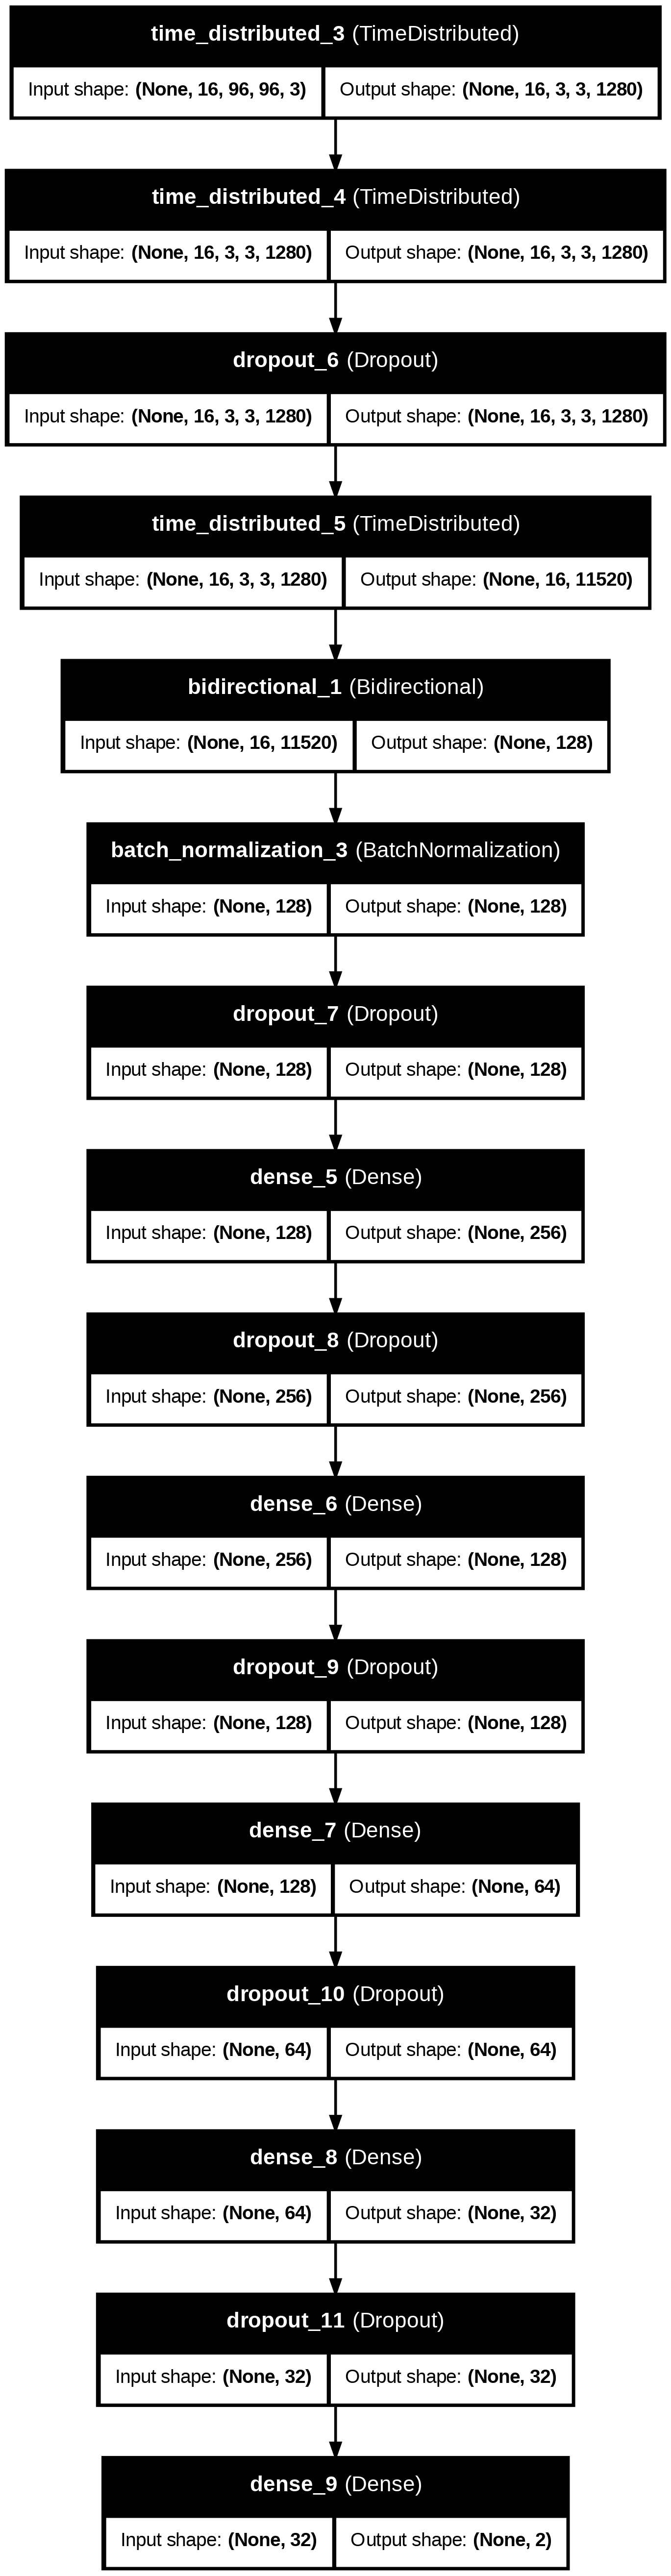

In [ ]:
model = build_model()

from tensorflow.keras.utils import plot_model
plot_model(
    model,
    to_file='MobBiLSTM_model_structure_plot.png',
    show_shapes=True,
    show_layer_names=True
)


# Specifying Callbacks and Fitting

In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

checkpoint_filepath = "/content/best_MoBiLSTM_model.keras"


model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)


early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=40,
    restore_best_weights=True,
    verbose=1
)


reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.6,
    patience=10,
    min_lr=0.00005,
    verbose=1
)




# Compile the model
model.compile(
    loss="categorical_crossentropy",
    optimizer="sgd",
    metrics=["accuracy"]
)


In [ ]:
MoBiLSTM_model_history = model.fit(
    x=features_train,
    y=labels_train,
    epochs=20,
    batch_size=8,
    shuffle=True,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr, model_checkpoint]
)

# Model Evaluation

In [ ]:
def plot_metric(model_training_history, metric_name_1, metric_name_2, plot_name):

    metric_value_1 = model_training_history.history[metric_name_1]
    metric_value_2 = model_training_history.history[metric_name_2]

    epochs = range(len(metric_value_1))

    plt.plot(epochs, metric_value_1, 'blue', label = metric_name_1)
    plt.plot(epochs, metric_value_2, 'orange', label = metric_name_2)

    plt.title(str(plot_name))

    plt.legend()

In [2]:
from tensorflow.keras.models import load_model

# Load the best saved model
model = load_model("/content/best_MoBiLSTM_model.keras")

# Verify the model structure
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ time_distributed (TimeDistributed)   │ (None, 16, 3, 3, 1280)      │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_1 (TimeDistributed) │ (None, 16, 3, 3, 1280)      │           5,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16, 3, 3, 1280)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_2 (TimeDistributed) │ (None, 16, 11520)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 128)                 │       5,931,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 2)                   │              66 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,271,460 (31.55 MB)

 Trainable params: 7,692,194 (29.34 MB)

 Non-trainable params: 579,264 (2.21 MB)

 Optimizer params: 2 (12.00 B)

In [ ]:


import matplotlib.pyplot as plt

loaded_model = tf.keras.models.load_model('/content/drive/MyDrive/Honours /Models/mobilstm_model.keras/mobilstm_model.keras')

if hasattr(loaded_model, 'history'):
    plot_metric(loaded_model.history, 'loss', 'val_loss', 'Total Loss vs Total Validation Loss')
else:
    print("Model history not found. Please ensure you trained the model using fit() method.")

plt.savefig('loss_vs_val_loss_plot.png', dpi=300, bbox_inches='tight')

plt.show()



Model history not found. Please ensure you trained the model using fit() method.


<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

plot_metric(MoBiLSTM_model_history, 'accuracy', 'val_accuracy', 'Total Accuracy vs Validation Accuracy')

plt.savefig('accuracy_vs_val_accuracy_plot.png', dpi=300, bbox_inches='tight')

plt.show()


# **Predicting the Test Set**

In [15]:
def resize_frames(frames):
    """Resizes frames to the expected input shape of the model."""
    resized_frames = []
    for frame in frames:
        resized_frame = cv2.resize(frame, (64, 64))  # Resize to 64x64
        resized_frames.append(resized_frame)
    return np.array(resized_frames)

# Resize frames in features_test before prediction
features_test_resized = np.array([resize_frames(clip) for clip in features_test])

# Now, make the prediction using the resized frames
labels_predict = model.predict(features_test_resized)

7/7 [==============================] - 15s 1s/step


In [11]:
labels_predict = model.predict(features_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 57s 6s/step


In [12]:
labels_predict = np.argmax(labels_predict , axis=1)
labels_test_normal = np.argmax(labels_test , axis=1)

In [15]:
labels_test_normal.shape , labels_predict.shape

((200,), (200,))

# Accuracy Score

In [13]:
from sklearn.metrics import accuracy_score
AccScore = accuracy_score(labels_predict, labels_test_normal)
print('Accuracy Score is : ', AccScore)

Accuracy Score is :  0.985


# Confusion Matrix

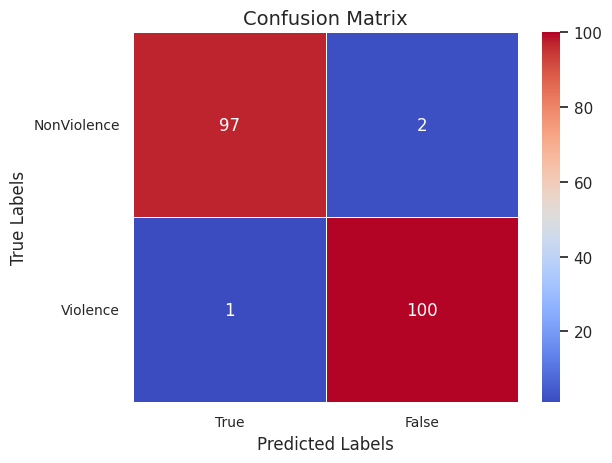

In [14]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(labels_test_normal, labels_predict)

fig, ax = plt.subplots()

sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='coolwarm', linewidths=0.5)

ax.set_xlabel('Predicted Labels', fontsize=12)
ax.set_ylabel('True Labels', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14)

ax.set_xticklabels(['True', 'False'], fontsize=10)
ax.set_yticklabels(['NonViolence', 'Violence'], fontsize=10, rotation=0)

plt.tight_layout()

plt.show()


### **Confusion Matrix Summary**  

| **True Labels / Predicted Labels** | **True (NonViolence)** | **False (Violence)** |  
|------------------------------------|------------------------|-----------------------|  
| **NonViolence**                    | 97 (True Positive)     | 2 (False Negative)    |  
| **Violence**                        | 1 (False Positive)     | 100 (True Negative)   |  

---

### **Key Metrics**  

- **True Positives (TP):** 97 cases where "NonViolence" was correctly predicted.  
- **True Negatives (TN):** 100 cases where "Violence" was correctly predicted.  
- **False Positives (FP):** 1 case where "Violence" was incorrectly predicted as "NonViolence."  
- **False Negatives (FN):** 2 cases where "NonViolence" was incorrectly predicted as "Violence."  

---

### **Performance Metrics**  

1. **Accuracy:**  
   \[
   \text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} = \frac{97 + 100}{97 + 100 + 1 + 2} = \frac{197}{200} = 0.985 \, (98.5\%)
   \]

2. **Precision (for NonViolence):**  
   \[
   \text{Precision} = \frac{TP}{TP + FP} = \frac{97}{97 + 1} = \frac{97}{98} \approx 0.9898 \, (98.98\%)
   \]

3. **Recall (for NonViolence):**  
   \[
   \text{Recall} = \frac{TP}{TP + FN} = \frac{97}{97 + 2} = \frac{97}{99} \approx 0.9798 \, (97.98\%)
   \]

4. **F1-Score (for NonViolence):**  
   \[
   \text{F1-Score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} = 2 \cdot \frac{0.9898 \times 0.9798}{0.9898 + 0.9798} \approx 0.9848 \, (98.48\%)
   \]

5. **Recall (for Violence):**  
   \[
   \text{Recall} = \frac{TN}{TN + FP} = \frac{100}{100 + 1} = \frac{100}{101} \approx 0.9901 \, (99.01\%)
   \]

---

### **Inferences**  

1. The model has **very high accuracy (98.5%)**, indicating strong overall performance.  
2. The **precision for "NonViolence" is 98.98%**, meaning very few false positives occur.  
3. The **recall for "NonViolence" is 97.98%**, slightly lower due to two false negatives.  
4. The **recall for "Violence" is 99.01%**, indicating that the model effectively detects violent content.  
5. The **F1-score for "NonViolence" is 98.48%**, showing a balanced trade-off between precision and recall.  


Classification Report

In [16]:
from sklearn.metrics import classification_report

report = classification_report(labels_test_normal, labels_predict)

print("Detailed Classification Report:\n")
print(report)


Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.98        99
           1       0.98      0.99      0.99       101

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200



# Prediction Frame By Frame

In [22]:


def predict_frames(video_file_path, output_file_path, sequence_length, violence_threshold=0.3):

    # Read from the video file.
    video_reader = cv2.VideoCapture(video_file_path)

    # Get the width and height of the video.
    original_video_width = int(video_reader.get(cv2.CAP_PROP_FRAME_WIDTH))
    original_video_height = int(video_reader.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # VideoWriter to store the output video in the disk.
    video_writer = cv2.VideoWriter(output_file_path, cv2.VideoWriter_fourcc('m', 'p', '4', 'v'),
                                    video_reader.get(cv2.CAP_PROP_FPS), (original_video_width, original_video_height))

    # Declare a queue to store video frames.
    frames_queue = deque(maxlen=sequence_length)

    # Store the predicted class in the video.
    predicted_class_name = ''

    # Counter to track the number of "Violence" frames
    violence_frame_count = 0
    total_frame_count = 0

    # Iterate until the video is accessed successfully.
    while video_reader.isOpened():

        ok, frame = video_reader.read()

        if not ok:
            break

        # Resize the Frame to fixed Dimensions.
        resized_frame = cv2.resize(frame, (frame_height, frame_width))

        # Normalize the resized frame
        normalized_frame = resized_frame / 255

        # Appending the pre-processed frame into the frames list.
        frames_queue.append(normalized_frame)

        # We Need at Least number of SEQUENCE_LENGTH Frames to perform a prediction.
        # Check if the number of frames in the queue are equal to the fixed sequence length.
        if len(frames_queue) == sequence_length:

            # Pass the normalized frames to the model and get the predicted probabilities.
            predicted_labels_probabilities = model.predict(np.expand_dims(frames_queue, axis=0))[0]

            # Get the index of class with highest probability.
            predicted_label = np.argmax(predicted_labels_probabilities)

            # Get the class name using the retrieved index.
            predicted_class_name = class_labels[predicted_label]

            # Count the number of "Violence" frames
            total_frame_count += 1
            if predicted_class_name == "Violence":
                violence_frame_count += 1

        # Write predicted class name on top of the frame.
        if predicted_class_name == "Violence":
            cv2.putText(frame, predicted_class_name, (5, 100), cv2.FONT_HERSHEY_SIMPLEX, 3, (0, 0, 255), 12)
        else:
            cv2.putText(frame, predicted_class_name, (5, 100), cv2.FONT_HERSHEY_SIMPLEX, 3, (0, 255, 0), 12)

        # Write The frame into the disk using the VideoWriter
        video_writer.write(frame)

    # After processing all frames, check if the number of violence frames exceeds the threshold
    violence_ratio = violence_frame_count / total_frame_count if total_frame_count > 0 else 0

    if violence_ratio > violence_threshold:
        print("The video contains violence.")
    else:
        print("The video does not contain violence.")

    video_reader.release()
    video_writer.release()


In [18]:
import matplotlib.pyplot as plt
plt.style.use("default")

# To show Random Frames from the saved output predicted video (output predicted video doesn't show on the notebook but can be downloaded)
def show_pred_frames(pred_video_path):

    plt.figure(figsize=(20,15))

    video_reader = cv2.VideoCapture(pred_video_path)

    # Get the number of frames in the video.
    frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))

    # Get Random Frames from the video then Sort it
    random_range = sorted(random.sample(range (sequence_length , frames_count ), 12))

    for counter, random_index in enumerate(random_range, 1):

        plt.subplot(5, 4, counter)

        # Set the current frame position of the video.
        video_reader.set(cv2.CAP_PROP_POS_FRAMES, random_index)

        ok, frame = video_reader.read()

        if not ok:
          break

        frame = cv2.cvtColor(frame , cv2.COLOR_BGR2RGB)

        plt.imshow(frame);ax.figure.set_size_inches(20,20);plt.tight_layout()

    video_reader.release()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 589ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 609ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 580ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 580ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 574ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 519ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 786ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 752ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 502ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

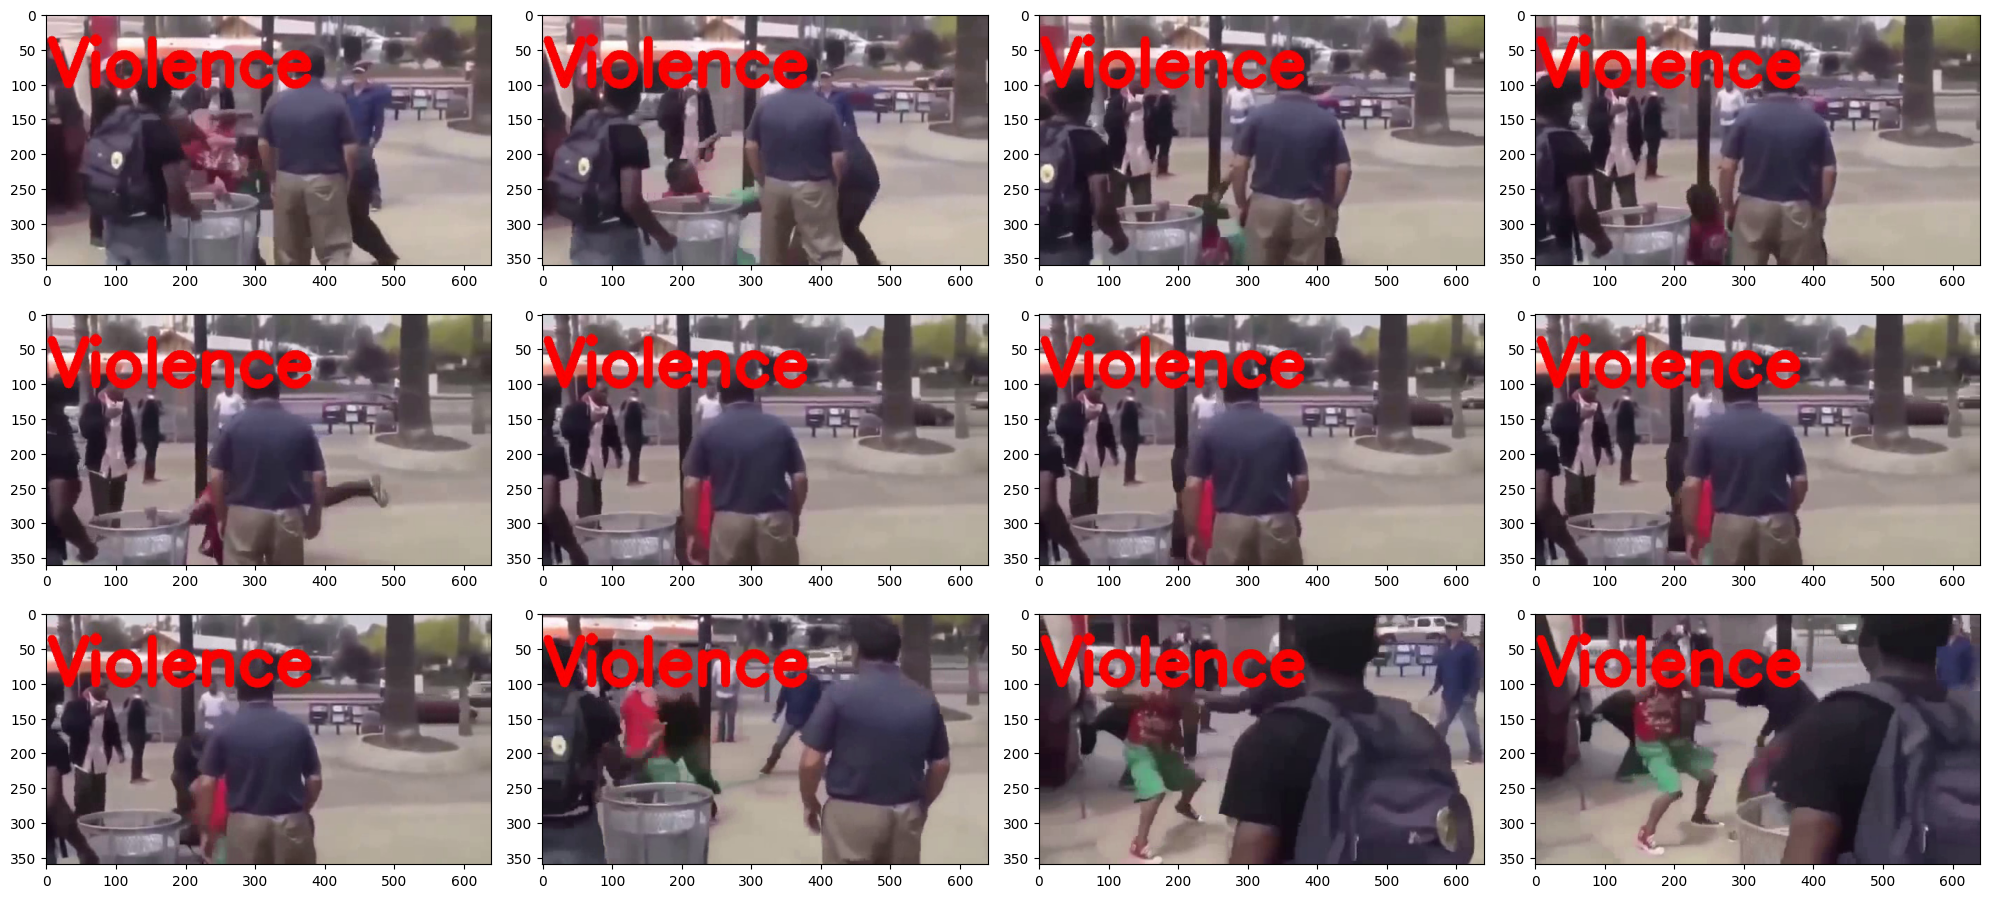

In [23]:
# Specifying video to be predicted
input_video_file_path = "/content/drive/MyDrive/IS/Honours/Real Life Violence Dataset/Violence/V_100.mp4"
output_video_file_path = "/content/test.mp4"
# Perform Prediction on the Test Video.
predict_frames(input_video_file_path, output_video_file_path, sequence_length)

# Show random frames from the output video
show_pred_frames(output_video_file_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

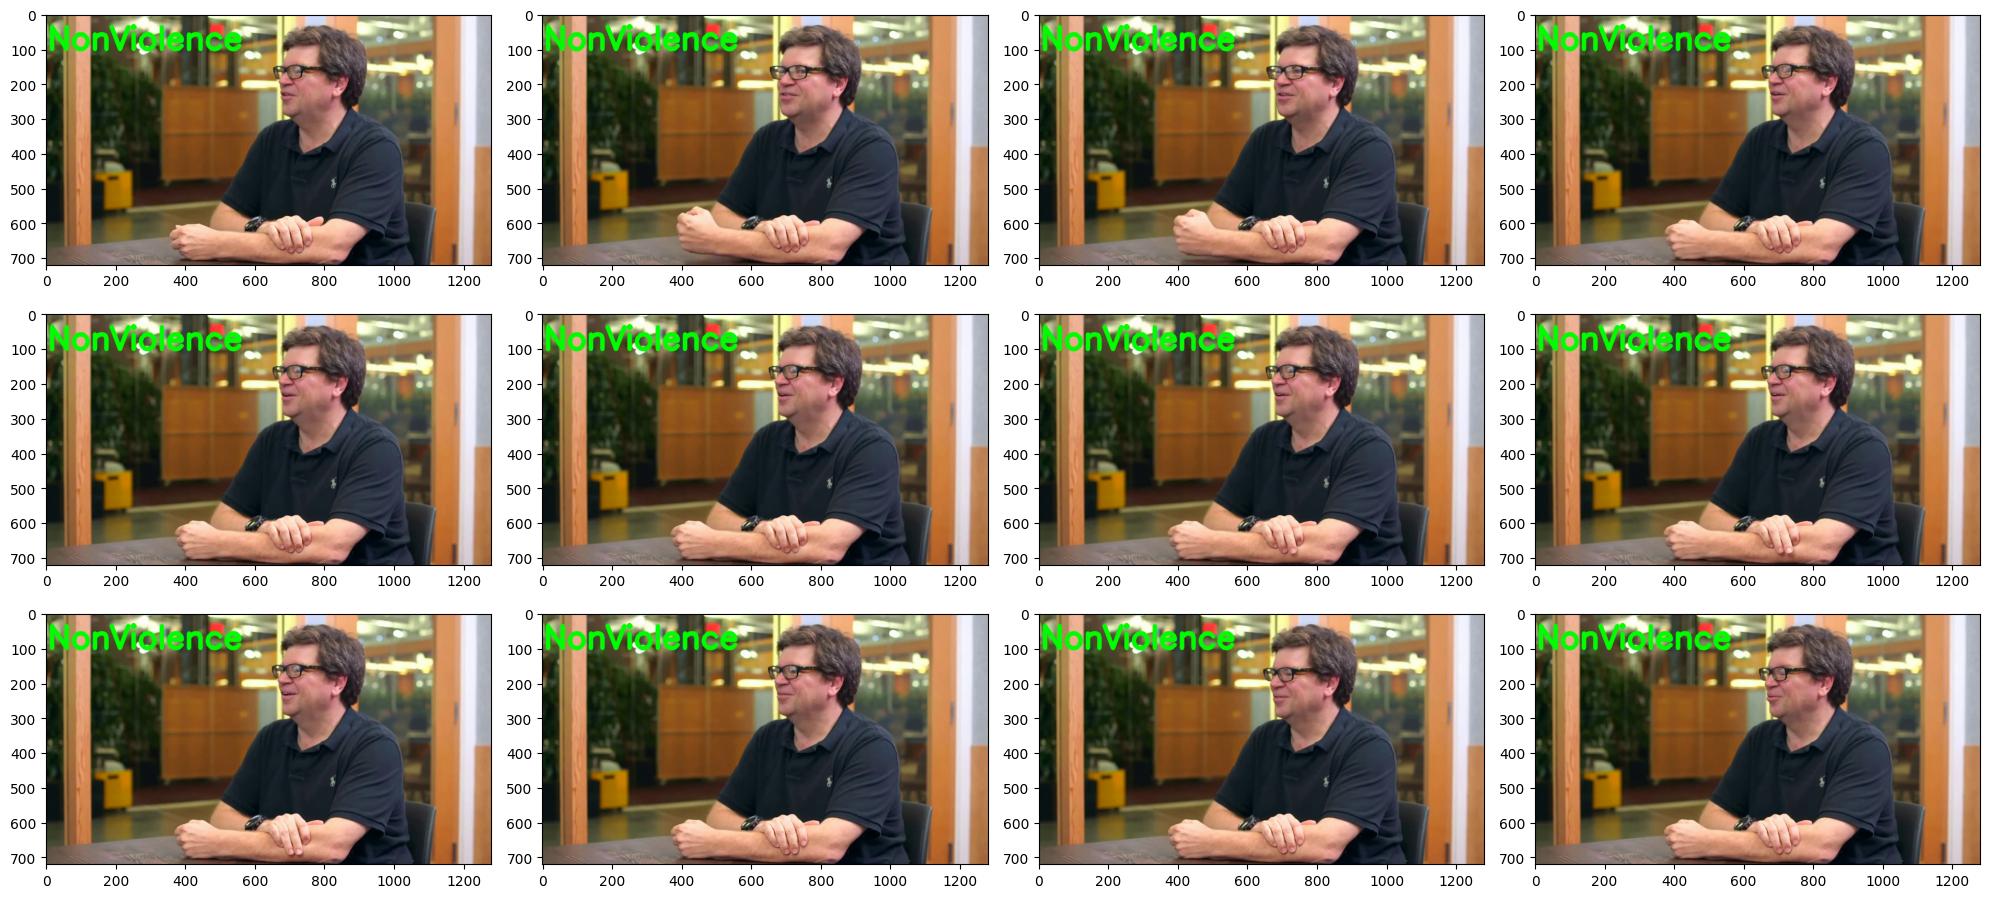

In [24]:
# Specifying video to be predicted
input_video_file_path = "/content/drive/MyDrive/IS/Honours/Real Life Violence Dataset/NonViolence/NV_1000.mp4"
output_video_file_path = "/content/test.mp4"
# Perform Prediction on the Test Video.
predict_frames(input_video_file_path, output_video_file_path, sequence_length)

# Show random frames from the output video
show_pred_frames(output_video_file_path)

In [ ]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.4/321.4 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.8/94.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 5.7 MB/s eta 0:00:00
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 3.0.2
    Uninstalling MarkupSafe-3.0.2:
      Successfully uninstalled MarkupSafe-3.0.2


In [ ]:
import os
import cv2
import numpy as np
from tensorflow.keras.models import load_model
import gradio as gr

# Load the pre-trained model
model = load_model('/content/drive/MyDrive/Honours/mobilstm_model.keras')

# Load Haar Cascade for face or body detection
haar_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

# Frame dimensions and sequence length
frame_height, frame_width = 96, 96
sequence_length = 16

# Preprocess frames for model input
def preprocess_frames(frames):
    processed = [cv2.resize(frame, (frame_width, frame_height)).astype(
        'float32') / 255.0 for frame in frames]
    return np.expand_dims(processed, axis=0)  # Add batch dimension

# Extract frames and apply Haar Cascade
def extract_frames_with_haar(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Convert to grayscale for Haar Cascade
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Detect bodies or faces
        detections = haar_cascade.detectMultiScale(
            gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

        # Crop the first detected region or use the entire frame if no detection
        if len(detections) > 0:
            x, y, w, h = detections[0]  # Take the first detected region
            cropped_frame = frame[y:y+h, x:x+w]
        else:
            cropped_frame = frame

        frames.append(cropped_frame)

    cap.release()
    return frames

# Classify frames in sequences of 16
def classify_frames(video_path):
    frames = extract_frames_with_haar(video_path)
    violence_score = 0
    non_violence_score = 0

    # Pad frames if less than sequence_length
    if len(frames) < sequence_length:
        frames += [frames[-1]] * (sequence_length - len(frames))

    for i in range(0, len(frames) - sequence_length + 1, sequence_length):
        frame_sequence = frames[i:i + sequence_length]
        processed_frames = preprocess_frames(frame_sequence)
        prediction = model.predict(processed_frames)[0]  # Probabilities for each class

        # Aggregate probabilities
        violence_score += prediction[1]  # Assuming index 1 corresponds to "Violence"
        non_violence_score += prediction[0]  # Assuming index 0 corresponds to "Non-Violence"

    # Determine the dominant label based on aggregated scores
    if violence_score > non_violence_score:
        return "Violence"
    else:
        return "Non-Violence"

# Gradio interface
def process_and_display(video_file):
    label = classify_frames(video_file)
    return f"Detected Label: {label}"

interface = gr.Interface(
    fn=process_and_display,
    inputs=gr.Video(label="Upload a Video"),
    outputs=gr.Textbox(label="Detection Result"),
    title="Violence Detection System",
    description="Upload a video to detect whether it contains violent or non-violent scenes."
)

if __name__ == "__main__":
    interface.launch()


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 63 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7bed493bebca063df0.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
